=== DATASET ===
       experience   salaire
count      100.00    100.00
mean         9.40  58205.44
std          5.95  17748.86
min          0.11  28116.52
25%          3.86  43187.87
50%          9.28  55849.15
75%         14.60  73851.97
max         19.74  93122.33

Train : 80 exemples
Test  : 20 exemples

=== RÉSULTATS ===
Intercept (w₀) : 30714.57
Coefficient (w₁) : 2899.66
RMSE : 4042.58
R² : 0.9507

Formule : salaire = 30715 + 2900 × experience


/Users/zooherhoussen/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


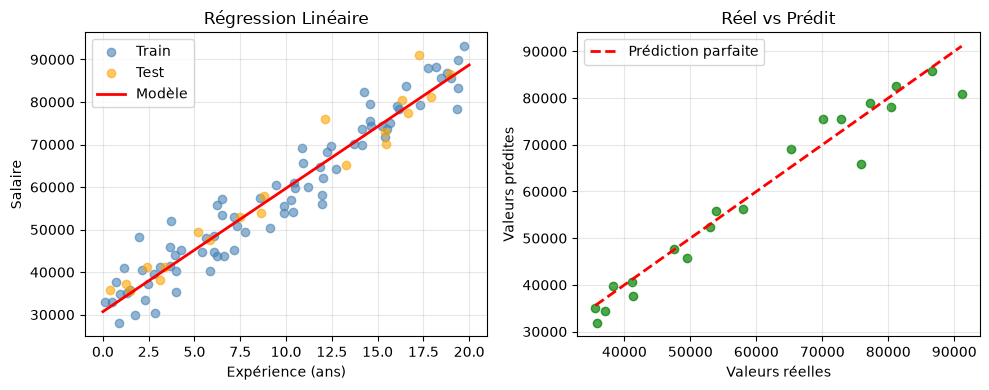

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Dataset : prédire le salaire en fonction de l'expérience
np.random.seed(42)
experience = np.random.uniform(0, 20, 100)
salaire = 30000 + 3000 * experience + np.random.normal(0, 5000, 100)

df = pd.DataFrame({"experience": experience, "salaire": salaire})

print("=== DATASET ===")
print(df.describe().round(2))

# Split train/test
X = df[["experience"]]   # features (2D obligatoire)
y = df["salaire"]        # target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTrain : {len(X_train)} exemples")
print(f"Test  : {len(X_test)} exemples")

# Entraîner le modèle
model = LinearRegression()
model.fit(X_train, y_train)

# Prédire
y_pred = model.predict(X_test)

# Évaluer
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"\n=== RÉSULTATS ===")
print(f"Intercept (w₀) : {model.intercept_:.2f}")
print(f"Coefficient (w₁) : {model.coef_[0]:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R² : {r2:.4f}")
print(f"\nFormule : salaire = {model.intercept_:.0f} + {model.coef_[0]:.0f} × experience")

# Visualisation
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(X_train, y_train, alpha=0.6, label="Train", color="steelblue")
plt.scatter(X_test, y_test, alpha=0.6, label="Test", color="orange")
x_line = np.linspace(0, 20, 100).reshape(-1, 1)
plt.plot(x_line, model.predict(x_line), color="red", linewidth=2, label="Modèle")
plt.xlabel("Expérience (ans)"); plt.ylabel("Salaire")
plt.title("Régression Linéaire"); plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred, alpha=0.7, color="green")
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         "r--", linewidth=2, label="Prédiction parfaite")
plt.xlabel("Valeurs réelles"); plt.ylabel("Valeurs prédites")
plt.title("Réel vs Prédit"); plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Admis : 110 | Refusés : 90

=== RÉSULTATS ===
Accuracy : 0.9500

Rapport de classification :
              precision    recall  f1-score   support

      Refusé       0.89      1.00      0.94        17
       Admis       1.00      0.91      0.95        23

    accuracy                           0.95        40
   macro avg       0.95      0.96      0.95        40
weighted avg       0.96      0.95      0.95        40



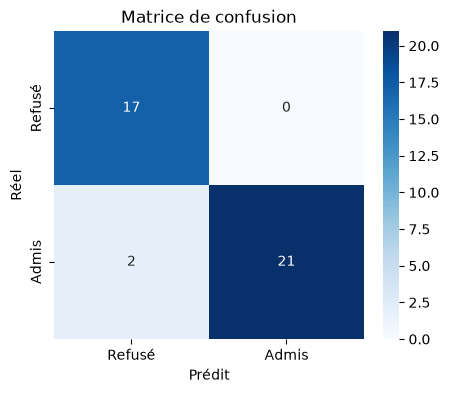

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# Dataset : prédire si un candidat est admis (1) ou refusé (0)
np.random.seed(42)
n = 200
note_math = np.random.normal(60, 15, n)
note_english = np.random.normal(60, 15, n)
admis = ((note_math + note_english) / 2 > 60).astype(int)

df = pd.DataFrame({
    "note_math": note_math,
    "note_english": note_english,
    "admis": admis
})

print(f"Admis : {admis.sum()} | Refusés : {(admis==0).sum()}")

# Split
X = df[["note_math", "note_english"]]
y = df["admis"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalisation
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modèle
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# Évaluation
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(f"\n=== RÉSULTATS ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"\nRapport de classification :")
print(classification_report(y_test, y_pred, 
      target_names=["Refusé", "Admis"]))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Refusé", "Admis"],
            yticklabels=["Refusé", "Admis"])
plt.title("Matrice de confusion")
plt.ylabel("Réel"); plt.xlabel("Prédit")
plt.show()

=== COMPARAISON DES MODÈLES ===
Logistic Regression       → Accuracy : 0.8350
Decision Tree             → Accuracy : 0.8950
Random Forest             → Accuracy : 0.9400
Gradient Boosting         → Accuracy : 0.9600


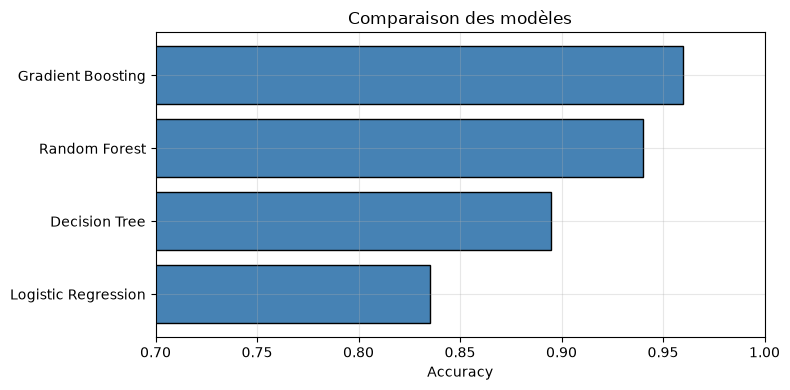

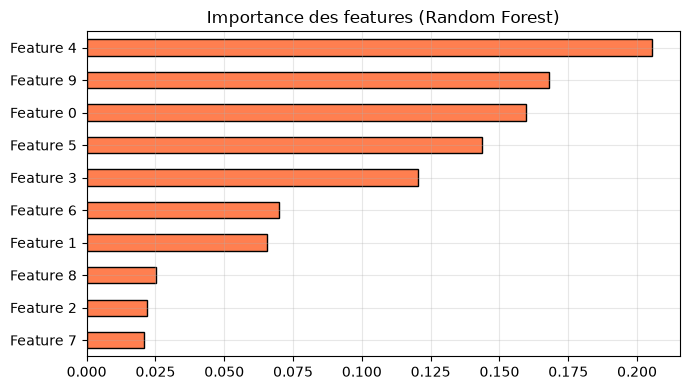

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification

# Dataset plus complexe
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=5,
    n_redundant=2,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Comparer plusieurs modèles
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

modeles = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree":       DecisionTreeClassifier(random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(random_state=42)
}

print("=== COMPARAISON DES MODÈLES ===")
resultats = {}
for nom, modele in modeles.items():
    modele.fit(X_train, y_train)
    acc = accuracy_score(y_test, modele.predict(X_test))
    resultats[nom] = acc
    print(f"{nom:25s} → Accuracy : {acc:.4f}")

# Visualisation
plt.figure(figsize=(8, 4))
plt.barh(list(resultats.keys()), list(resultats.values()), 
         color="steelblue", edgecolor="black")
plt.xlim(0.7, 1.0)
plt.xlabel("Accuracy")
plt.title("Comparaison des modèles")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Feature importance du Random Forest
rf = modeles["Random Forest"]
importances = pd.Series(rf.feature_importances_,
                        index=[f"Feature {i}" for i in range(10)])
importances.sort_values().plot(kind="barh", figsize=(7, 4),
                               color="coral", edgecolor="black")
plt.title("Importance des features (Random Forest)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

XGBoost Accuracy : 0.9600


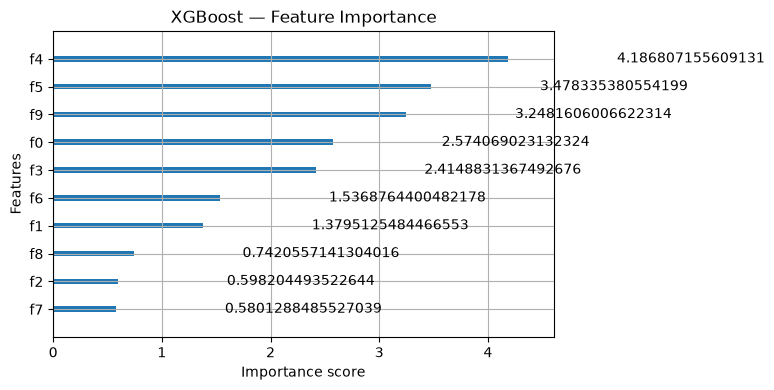

LightGBM Accuracy : 0.9500

=== RÉSUMÉ FINAL ===
Random Forest  : 0.9400
Gradient Boost : 0.9600
XGBoost        : 0.9600
LightGBM       : 0.9500


/Users/zooherhoussen/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [7]:
import xgboost as xgb
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Dataset
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=5,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    verbosity=0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

y_pred = xgb_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"XGBoost Accuracy : {acc:.4f}")

# Feature importance
plt.figure(figsize=(8, 4))
xgb.plot_importance(xgb_model, ax=plt.gca(), 
                    importance_type="gain",
                    title="XGBoost — Feature Importance")
plt.tight_layout()
plt.show()

# LightGBM
import lightgbm as lgb

lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1
)

lgb_model.fit(X_train, y_train)
y_pred_lgb = lgb_model.predict(X_test)
acc_lgb = accuracy_score(y_test, y_pred_lgb)
print(f"LightGBM Accuracy : {acc_lgb:.4f}")

print("\n=== RÉSUMÉ FINAL ===")
print(f"Random Forest  : 0.9400")
print(f"Gradient Boost : 0.9600")
print(f"XGBoost        : {acc:.4f}")
print(f"LightGBM       : {acc_lgb:.4f}")

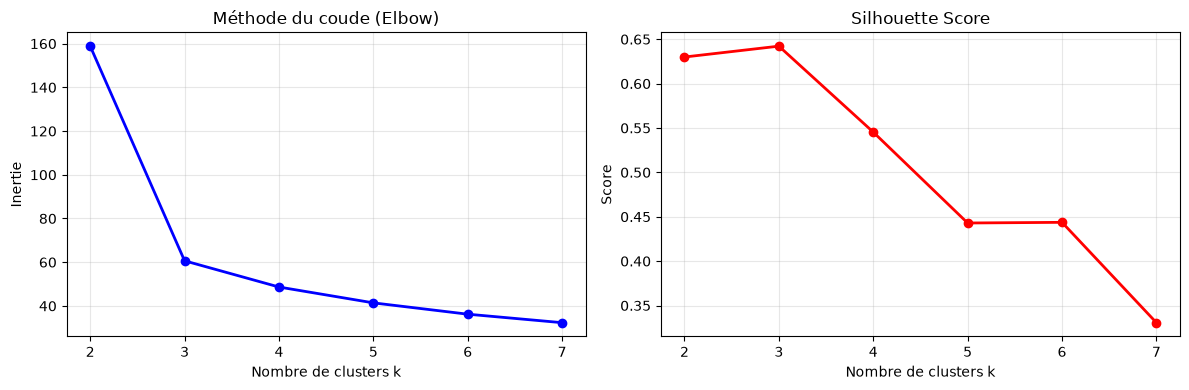

Silhouette Score (k=3) : 0.6422
Distribution des clusters : {1: 101, 0: 100, 2: 99}


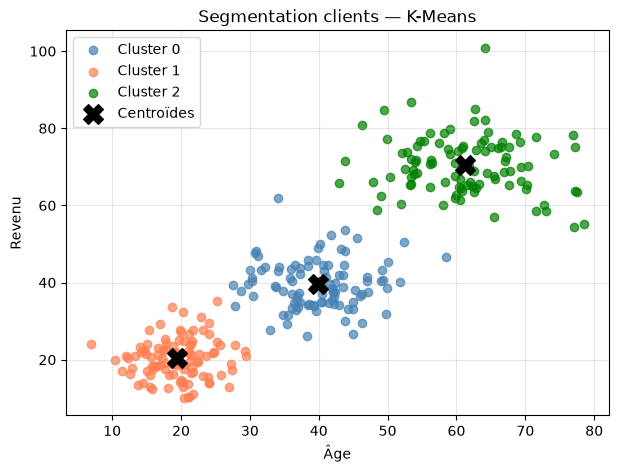

In [8]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Dataset : clients d'un magasin
np.random.seed(42)
n = 300

# 3 groupes de clients distincts
groupe1 = np.random.normal([20, 20], 5, (100, 2))   # jeunes, faible revenu
groupe2 = np.random.normal([60, 70], 8, (100, 2))   # âgés, revenu élevé
groupe3 = np.random.normal([40, 40], 6, (100, 2))   # intermédiaires

X = np.vstack([groupe1, groupe2, groupe3])
df = pd.DataFrame(X, columns=["age", "revenu"])

# Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Méthode du coude pour trouver k optimal
inertias = []
silhouettes = []
k_range = range(2, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_range, inertias, "bo-", linewidth=2)
axes[0].set_title("Méthode du coude (Elbow)")
axes[0].set_xlabel("Nombre de clusters k")
axes[0].set_ylabel("Inertie")
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_range, silhouettes, "ro-", linewidth=2)
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Nombre de clusters k")
axes[1].set_ylabel("Score")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# K-Means avec k=3
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = km_final.fit_predict(X_scaled)

print(f"Silhouette Score (k=3) : {silhouette_score(X_scaled, labels):.4f}")
print(f"Distribution des clusters : {pd.Series(labels).value_counts().to_dict()}")

# Visualisation des clusters
plt.figure(figsize=(7, 5))
colors = ["steelblue", "coral", "green"]
for cluster in range(3):
    mask = labels == cluster
    plt.scatter(X[mask, 0], X[mask, 1], 
                c=colors[cluster], label=f"Cluster {cluster}", alpha=0.7)

centroids = scaler.inverse_transform(km_final.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1], 
            c="black", marker="X", s=200, zorder=5, label="Centroïdes")
plt.xlabel("Âge"); plt.ylabel("Revenu")
plt.title("Segmentation clients — K-Means")
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

=== SVM (Support Vector Machine) ===
SVM Linear      → Accuracy : 0.8800
SVM RBF         → Accuracy : 0.8800
SVM Poly        → Accuracy : 0.8400

=== KNN (K-Nearest Neighbors) ===
k= 1 → Accuracy : 0.9300
k= 3 → Accuracy : 0.9300
k= 5 → Accuracy : 0.9300
k= 7 → Accuracy : 0.9300
k=10 → Accuracy : 0.9200
k=15 → Accuracy : 0.9100
k=20 → Accuracy : 0.9000


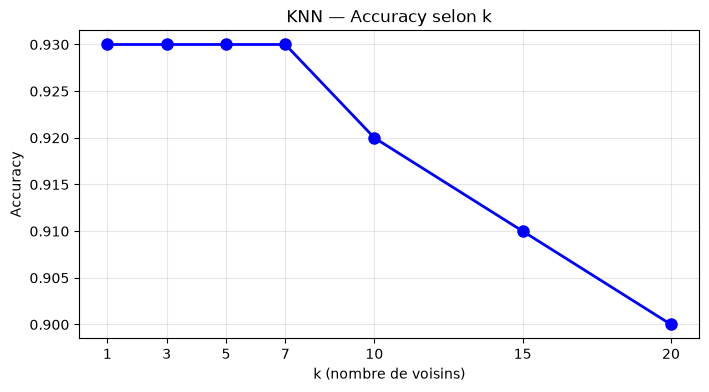


Meilleur k : 1 → Accuracy : 0.9300


In [1]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import matplotlib.pyplot as plt

# Dataset
X, y = make_classification(
    n_samples=500, n_features=2,
    n_informative=2, n_redundant=0,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# SVM
print("=== SVM (Support Vector Machine) ===")
svm_models = {
    "SVM Linear":  SVC(kernel="linear", C=1.0),
    "SVM RBF":     SVC(kernel="rbf", C=1.0, gamma="scale"),
    "SVM Poly":    SVC(kernel="poly", degree=3, C=1.0)
}

for nom, model in svm_models.items():
    model.fit(X_train_s, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_s))
    print(f"{nom:15s} → Accuracy : {acc:.4f}")

# KNN
print("\n=== KNN (K-Nearest Neighbors) ===")
k_values = [1, 3, 5, 7, 10, 15, 20]
knn_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_s, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test_s))
    knn_scores.append(acc)
    print(f"k={k:2d} → Accuracy : {acc:.4f}")

# Visualisation KNN
plt.figure(figsize=(8, 4))
plt.plot(k_values, knn_scores, "bo-", linewidth=2, markersize=8)
plt.xlabel("k (nombre de voisins)")
plt.ylabel("Accuracy")
plt.title("KNN — Accuracy selon k")
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
plt.show()

best_k = k_values[np.argmax(knn_scores)]
print(f"\nMeilleur k : {best_k} → Accuracy : {max(knn_scores):.4f}")

=== DBSCAN ===
Clusters trouvés : 1
Outliers : 0

=== HYPERPARAMETER TUNING ===
Meilleurs paramètres : {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}
Meilleur score CV   : 0.9301
Score Test          : 0.9400


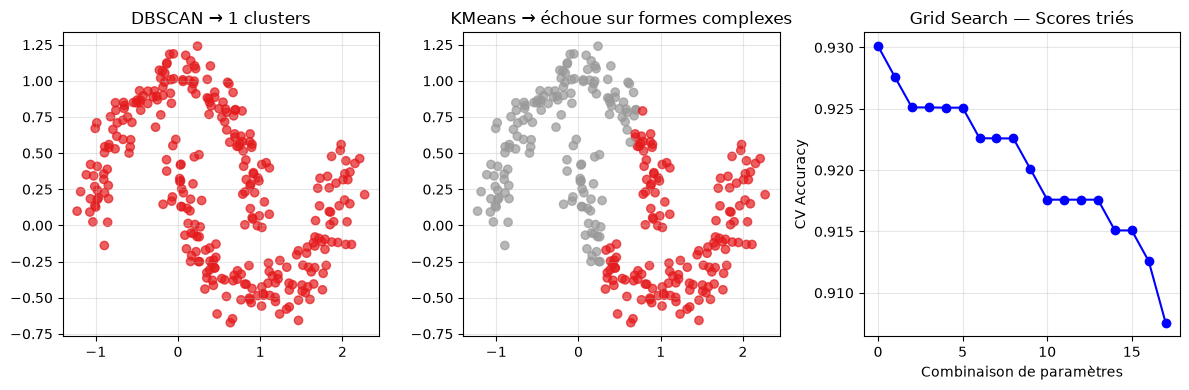

In [2]:
from sklearn.cluster import DBSCAN
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_moons
import numpy as np
import matplotlib.pyplot as plt

# DBSCAN — clustering de forme arbitraire
print("=== DBSCAN ===")
X_moons, _ = make_moons(n_samples=300, noise=0.1, random_state=42)

db = DBSCAN(eps=0.3, min_samples=5)
labels = db.fit_predict(X_moons)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_outliers = list(labels).count(-1)

print(f"Clusters trouvés : {n_clusters}")
print(f"Outliers : {n_outliers}")

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=labels, cmap="Set1", alpha=0.7)
plt.title(f"DBSCAN → {n_clusters} clusters")
plt.grid(True, alpha=0.3)

# Comparaison avec KMeans sur données en lune
from sklearn.cluster import KMeans
km = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_km = km.fit_predict(X_moons)

plt.subplot(1, 3, 2)
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=labels_km, cmap="Set1", alpha=0.7)
plt.title("KMeans → échoue sur formes complexes")
plt.grid(True, alpha=0.3)

# HYPERPARAMETER TUNING
print("\n=== HYPERPARAMETER TUNING ===")
X, y = make_classification(n_samples=500, n_features=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Grid Search
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, None],
    "min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train, y_train)

print(f"Meilleurs paramètres : {grid_search.best_params_}")
print(f"Meilleur score CV   : {grid_search.best_score_:.4f}")
print(f"Score Test          : {accuracy_score(y_test, grid_search.predict(X_test)):.4f}")

# Visualiser les résultats
results = grid_search.cv_results_
plt.subplot(1, 3, 3)
plt.plot(sorted(results["mean_test_score"], reverse=True), "bo-")
plt.title("Grid Search — Scores triés")
plt.xlabel("Combinaison de paramètres")
plt.ylabel("CV Accuracy")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

=== COMPARAISON RÉGRESSION RÉGULARISÉE ===

Linear Regression         → RMSE: 37.86 | R²: 0.8813 | Coefs≈0: 0/50
Ridge (L2, α=1)           → RMSE: 37.68 | R²: 0.8824 | Coefs≈0: 0/50
Ridge (L2, α=10)          → RMSE: 37.76 | R²: 0.8819 | Coefs≈0: 0/50
Lasso (L1, α=1)           → RMSE: 33.96 | R²: 0.9045 | Coefs≈0: 17/50
Lasso (L1, α=0.1)         → RMSE: 37.27 | R²: 0.8849 | Coefs≈0: 3/50
ElasticNet                → RMSE: 37.38 | R²: 0.8842 | Coefs≈0: 1/50


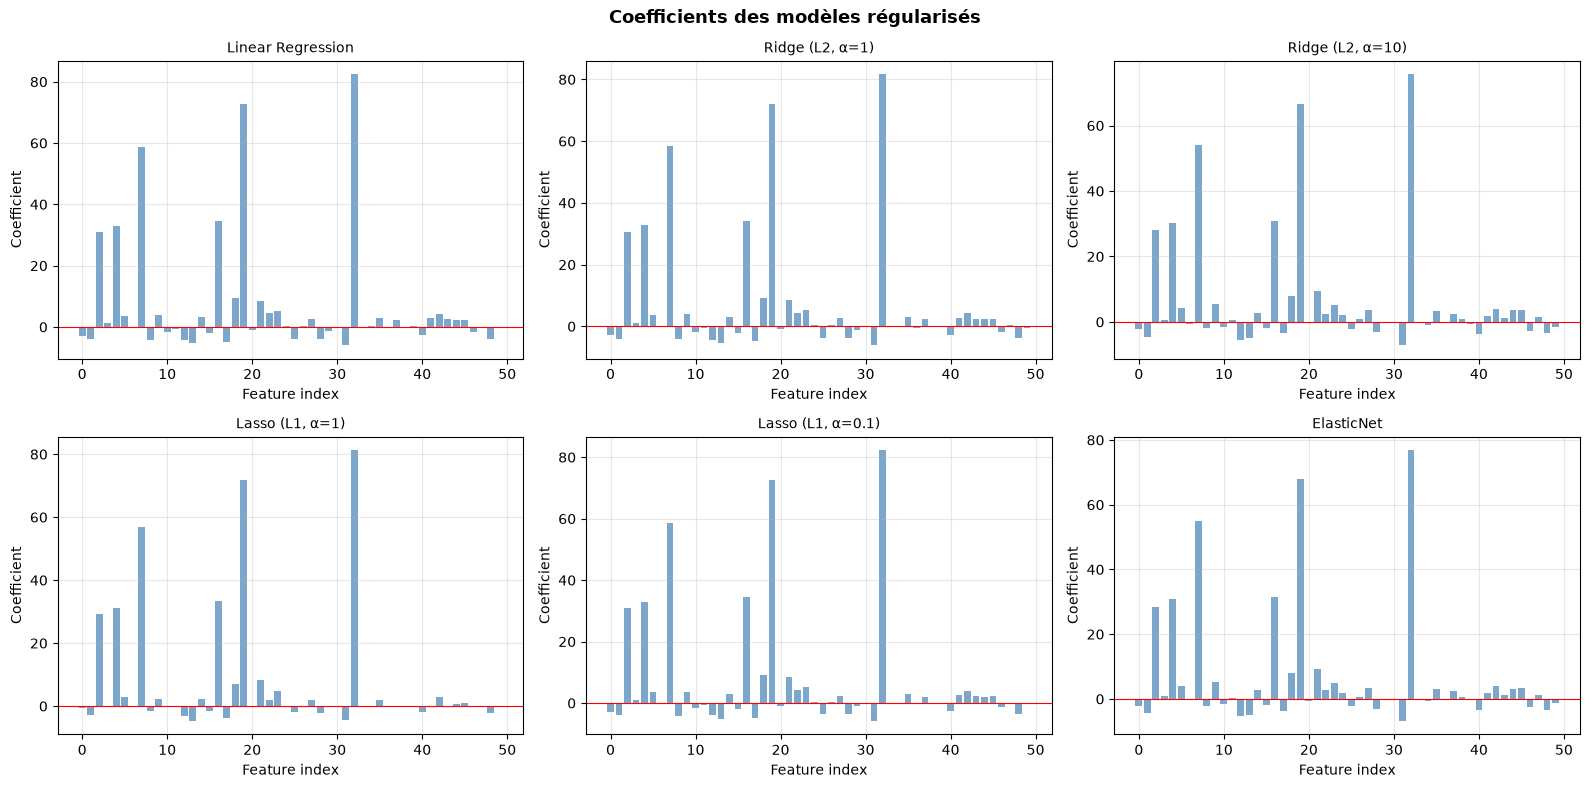


=== EXPLICATION ===

Linear Regression → coefficients libres → peuvent exploser
Ridge (L2)        → minimise MSE + α×Σwᵢ² → réduit tous les coefs
Lasso (L1)        → minimise MSE + α×Σ|wᵢ| → force certains coefs à 0
ElasticNet        → combine L1 + L2 → compromis optimal

Lasso est particulièrement utile pour la sélection de features
car il élimine automatiquement les features inutiles (coef = 0)



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# RÉGRESSION RÉGULARISÉE
# Problème de la régression linéaire classique :
# Avec beaucoup de features, les coefficients peuvent exploser → overfitting
# Solution : ajouter une pénalité sur les coefficients

# Dataset avec beaucoup de features (dont certaines inutiles)
X, y = make_regression(
    n_samples=200,
    n_features=50,      # 50 features
    n_informative=10,   # mais seulement 10 vraiment utiles
    noise=30,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Comparer les modèles
modeles = {
    "Linear Regression": LinearRegression(),
    "Ridge (L2, α=1)":   Ridge(alpha=1.0),
    "Ridge (L2, α=10)":  Ridge(alpha=10.0),
    "Lasso (L1, α=1)":   Lasso(alpha=1.0),
    "Lasso (L1, α=0.1)": Lasso(alpha=0.1),
    "ElasticNet":         ElasticNet(alpha=0.1, l1_ratio=0.5)
}

print("=== COMPARAISON RÉGRESSION RÉGULARISÉE ===\n")
resultats = {}
for nom, model in modeles.items():
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    n_zero = np.sum(np.abs(model.coef_) < 0.01)
    resultats[nom] = {"RMSE": rmse, "R²": r2, "Coefs≈0": n_zero}
    print(f"{nom:25s} → RMSE: {rmse:.2f} | R²: {r2:.4f} | Coefs≈0: {n_zero}/50")

# Visualiser les coefficients
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, (nom, model) in zip(axes.flat, modeles.items()):
    ax.bar(range(50), model.coef_, color="steelblue", alpha=0.7)
    ax.axhline(0, color="red", linewidth=0.8)
    ax.set_title(nom, fontsize=10)
    ax.set_xlabel("Feature index")
    ax.set_ylabel("Coefficient")
    ax.grid(True, alpha=0.3)

plt.suptitle("Coefficients des modèles régularisés", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n=== EXPLICATION ===")
print("""
Linear Regression → coefficients libres → peuvent exploser
Ridge (L2)        → minimise MSE + α×Σwᵢ² → réduit tous les coefs
Lasso (L1)        → minimise MSE + α×Σ|wᵢ| → force certains coefs à 0
ElasticNet        → combine L1 + L2 → compromis optimal

Lasso est particulièrement utile pour la sélection de features
car il élimine automatiquement les features inutiles (coef = 0)
""")

Shape : (1797, 64) → 1797 images de 8x8 pixels
Classes : [0 1 2 3 4 5 6 7 8 9]

Calcul t-SNE en cours...
✅ t-SNE terminé !


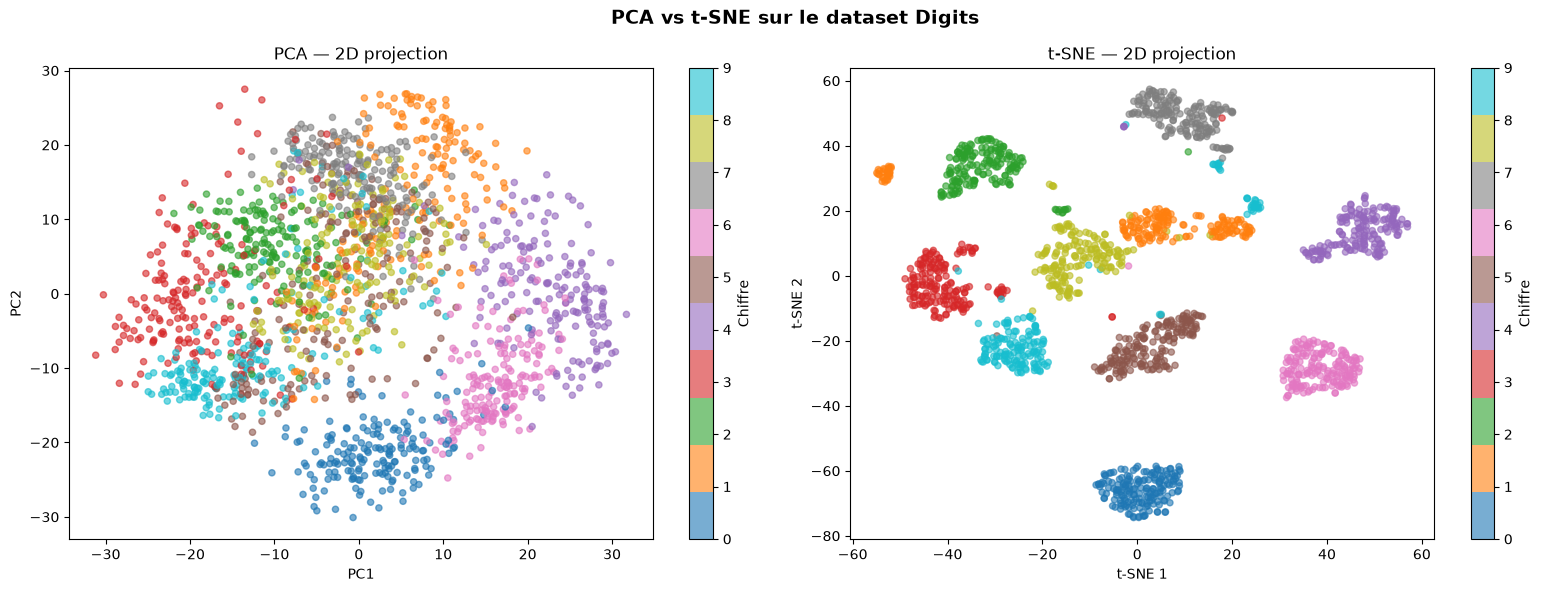


=== PCA vs t-SNE ===

PCA   → linéaire, rapide, préserve la variance globale
        Les clusters se chevauchent souvent

t-SNE → non-linéaire, lent, préserve la structure locale
        Sépare beaucoup mieux les clusters

Usage :
  PCA   → preprocessing, réduction de dimension avant ML
  t-SNE → visualisation exploratoire uniquement (pas pour ML)



In [2]:
from sklearn.manifold import TSNE
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
import numpy as np

# t-SNE — visualiser des données haute dimension en 2D
# Meilleur que PCA pour révéler des clusters complexes

# Dataset : chiffres manuscrits (64 features par image)
digits = load_digits()
X = digits.data    # (1797, 64)
y = digits.target  # 0-9

print(f"Shape : {X.shape} → 1797 images de 8x8 pixels")
print(f"Classes : {np.unique(y)}")

# PCA d'abord pour réduire la dimension (accélère t-SNE)
from sklearn.decomposition import PCA
pca = PCA(n_components=30)
X_pca = pca.fit_transform(X)

# t-SNE
print("\nCalcul t-SNE en cours...")


tsne = TSNE(n_components=2, perplexity=30, 
            learning_rate=200, max_iter=1000,
            random_state=42)
X_tsne = tsne.fit_transform(X_pca)
print("✅ t-SNE terminé !")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA 2D
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X)

scatter1 = axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                           c=y, cmap="tab10", alpha=0.6, s=20)
axes[0].set_title("PCA — 2D projection")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
plt.colorbar(scatter1, ax=axes[0], label="Chiffre")

# t-SNE 2D
scatter2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1],
                           c=y, cmap="tab10", alpha=0.6, s=20)
axes[1].set_title("t-SNE — 2D projection")
axes[1].set_xlabel("t-SNE 1"); axes[1].set_ylabel("t-SNE 2")
plt.colorbar(scatter2, ax=axes[1], label="Chiffre")

plt.suptitle("PCA vs t-SNE sur le dataset Digits", 
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n=== PCA vs t-SNE ===")
print("""
PCA   → linéaire, rapide, préserve la variance globale
        Les clusters se chevauchent souvent

t-SNE → non-linéaire, lent, préserve la structure locale
        Sépare beaucoup mieux les clusters

Usage :
  PCA   → preprocessing, réduction de dimension avant ML
  t-SNE → visualisation exploratoire uniquement (pas pour ML)
""")

=== ROC-AUC ===

Logistic Regression       → AUC: 0.9153
Random Forest             → AUC: 0.9411

=== PRECISION-RECALL ===

Logistic Regression       → AP: 0.8646
Random Forest             → AP: 0.9364


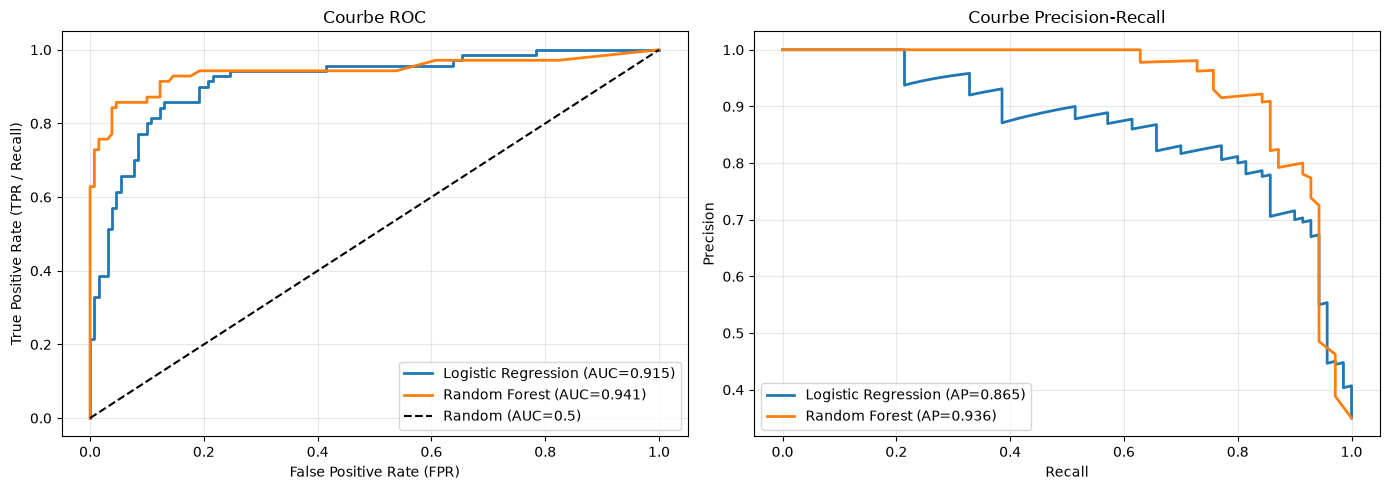


=== INTERPRÉTATION ===

ROC-AUC :
  1.0 = modèle parfait
  0.5 = modèle aléatoire (ligne diagonale)
  < 0.5 = pire qu'aléatoire

Quand utiliser ROC-AUC vs Accuracy ?
  → Dataset déséquilibré (70% classe 0, 30% classe 1)
  → ROC-AUC est plus fiable qu'Accuracy
  → Un modèle qui dit toujours "0" a 70% d'accuracy mais AUC=0.5

Precision-Recall :
  → Meilleur pour les datasets très déséquilibrés
  → Quand les faux positifs ET faux négatifs sont importants



In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_curve, roc_auc_score, 
                              precision_recall_curve, 
                              average_precision_score,
                              confusion_matrix, classification_report)
from sklearn.preprocessing import StandardScaler

# ROC-AUC — métrique clé pour la classification
X, y = make_classification(n_samples=1000, n_features=10, 
                            random_state=42, weights=[0.7, 0.3])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Entraîner plusieurs modèles
modeles = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

print("=== ROC-AUC ===\n")
for nom, model in modeles.items():
    model.fit(X_train_s, y_train)
    y_prob = model.predict_proba(X_test_s)[:, 1]
    
    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    
    axes[0].plot(fpr, tpr, linewidth=2, label=f"{nom} (AUC={auc:.3f})")
    print(f"{nom:25s} → AUC: {auc:.4f}")

# Ligne de référence (random classifier)
axes[0].plot([0,1], [0,1], "k--", label="Random (AUC=0.5)")
axes[0].set_xlabel("False Positive Rate (FPR)")
axes[0].set_ylabel("True Positive Rate (TPR / Recall)")
axes[0].set_title("Courbe ROC")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curve
print("\n=== PRECISION-RECALL ===\n")
for nom, model in modeles.items():
    y_prob = model.predict_proba(X_test_s)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    axes[1].plot(recall, precision, linewidth=2, 
                label=f"{nom} (AP={ap:.3f})")
    print(f"{nom:25s} → AP: {ap:.4f}")

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Courbe Precision-Recall")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== INTERPRÉTATION ===")
print("""
ROC-AUC :
  1.0 = modèle parfait
  0.5 = modèle aléatoire (ligne diagonale)
  < 0.5 = pire qu'aléatoire

Quand utiliser ROC-AUC vs Accuracy ?
  → Dataset déséquilibré (70% classe 0, 30% classe 1)
  → ROC-AUC est plus fiable qu'Accuracy
  → Un modèle qui dit toujours "0" a 70% d'accuracy mais AUC=0.5

Precision-Recall :
  → Meilleur pour les datasets très déséquilibrés
  → Quand les faux positifs ET faux négatifs sont importants
""")

=== OPTUNA — Optimisation bayésienne ===



  0%|          | 0/50 [00:00<?, ?it/s]


✅ Meilleurs paramètres : {'n_estimators': 134, 'max_depth': 8, 'min_samples_split': 9, 'min_samples_leaf': 1}
✅ Meilleur score      : 0.9420


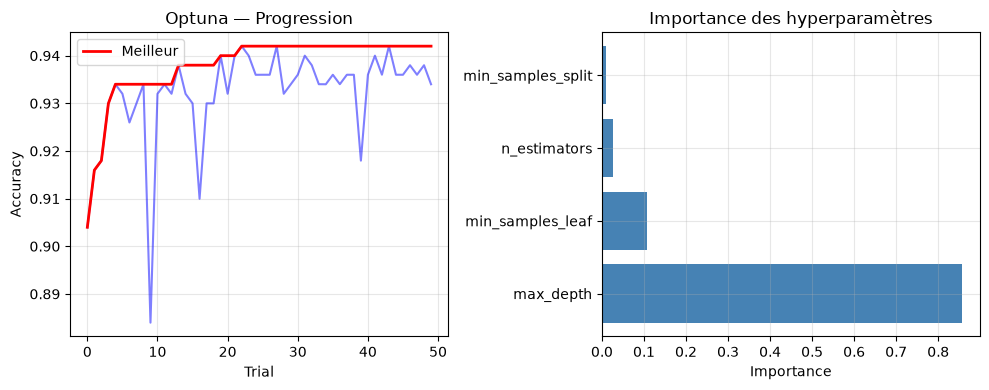


=== GRIDEARCH vs OPTUNA ===

GridSearch  → teste toutes les combinaisons → lent
RandomSearch → teste aléatoirement → rapide mais peu intelligent
Optuna      → optimisation bayésienne → apprend des essais précédents
              → converge plus vite vers les meilleurs paramètres



In [5]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.datasets import make_classification
import numpy as np

optuna.logging.set_verbosity(optuna.logging.WARNING)

X, y = make_classification(n_samples=500, n_features=10, random_state=42)

# OPTUNA — optimisation bayésienne des hyperparamètres
# Plus intelligent que GridSearch car apprend des essais précédents

def objective(trial):
    # Définir l'espace de recherche
    n_estimators = trial.suggest_int("n_estimators", 50, 300)
    max_depth = trial.suggest_int("max_depth", 2, 10)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 5)
    
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )
    
    score = cross_val_score(model, X, y, cv=3, scoring="accuracy").mean()
    return score

# Lancer l'optimisation
print("=== OPTUNA — Optimisation bayésienne ===\n")
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\n✅ Meilleurs paramètres : {study.best_params}")
print(f"✅ Meilleur score      : {study.best_value:.4f}")

# Visualiser l'historique
import matplotlib.pyplot as plt

trials_scores = [t.value for t in study.trials]
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(trials_scores, "b-", alpha=0.5)
plt.plot(np.maximum.accumulate(trials_scores), "r-", linewidth=2, label="Meilleur")
plt.xlabel("Trial"); plt.ylabel("Accuracy")
plt.title("Optuna — Progression")
plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
params = ["n_estimators", "max_depth", "min_samples_split", "min_samples_leaf"]
importances = optuna.importance.get_param_importances(study)
plt.barh(list(importances.keys()), list(importances.values()), color="steelblue")
plt.xlabel("Importance")
plt.title("Importance des hyperparamètres")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== GRIDEARCH vs OPTUNA ===")
print("""
GridSearch  → teste toutes les combinaisons → lent
RandomSearch → teste aléatoirement → rapide mais peu intelligent
Optuna      → optimisation bayésienne → apprend des essais précédents
              → converge plus vite vers les meilleurs paramètres
""")